In [62]:
# Install required packages first
!pip install -q transformers accelerate>=1.0.0 datasets>=3.0.0
!pip install -q av librosa soundfile resampy
!pip install -q scikit-learn matplotlib seaborn
!pip uninstall -y torch torchvision torchaudio
!pip install -q torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118
!pip install -q pytorchvideo
!pip install -q evaluate
!pip install -q datasets

^C
ERROR: Operation cancelled by user
^C
ERROR: Operation cancelled by user
^C
Fatal Python error: init_import_site: Failed to import the site module
Python runtime state: initialized
Traceback (most recent call last):
  File "<frozen importlib._bootstrap>", line 1360, in _find_and_load
  File "<frozen importlib._bootstrap>", line 1331, in _find_and_load_unlocked
  File "<frozen importlib._bootstrap>", line 935, in _load_unlocked
  File "<frozen importlib._bootstrap>", line 1176, in exec_module
  File "<frozen site>", line 652, in <module>
  File "<frozen site>", line 645, in main
  File "<frozen site>", line 584, in execsitecustomize
  File "/usr/lib/python3.12/sitecustomize.py", line 9, in <module>
    import wrapt
  File "/usr/local/lib/python3.12/dist-packages/wrapt/__init__.py", line 17, in <module>
    from .importer import (
  File "/usr/local/lib/python3.12/dist-packages/wrapt/importer.py", line 6, in <module>
    import importlib.metadata
  File "/usr/lib/python3.12/importlib/

UnboundLocalError: cannot access local variable 'child' where it is not associated with a value

In [ ]:
!pip install git+https://github.com/facebookresearch/TimeSformer.git --break-system-packages
!pip install einops timm --break-system-packages

In [ ]:
# !mkdir -p /kaggle/working/checkpoints/
# !cp -r /kaggle/input/datasets/nhatnam2610/train-full-video/checkpoints/checkpoint-700 /kaggle/working/checkpoints/checkpoint-700
# !cp -r /kaggle/input/datasets/nhatnam2610/train-full-video/checkpoints/checkpoint-1200 /kaggle/working/checkpoints/checkpoint-1200

In [ ]:
import sys
import os

dummy_path = "/kaggle/working/notebook.py"

# tạo file giả nếu chưa có
if not os.path.exists(dummy_path):
    with open(dummy_path, "w") as f:
        f.write("# dummy file")

# gán _file_ cho notebook
sys.modules["__main__"].__file__ = dummy_path

In [ ]:
import pandas as pd
import torch
import torch.nn as nn
import numpy as np
import os
import gc
import cv2
import warnings
from typing import Dict, List, Optional, Tuple, Union
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score, precision_score
from dataclasses import dataclass
import time
import subprocess
import sys
from contextlib import contextmanager, redirect_stderr
import io
# Transformers components
from transformers import (
    AutoTokenizer, AutoModel, AutoImageProcessor,
    TimesformerForVideoClassification,TimesformerConfig, Trainer, TrainingArguments, 
    EvalPrediction, PreTrainedModel, PretrainedConfig
)
from torch.utils.data import Dataset, DataLoader
import evaluate
from sentence_transformers import SentenceTransformer
import json
import matplotlib.pyplot as plt

In [ ]:
def fix_kaggle_path(old_path):
            if "extra_tikharm" in old_path:
            # 1. Xóa chuỗi (nên xóa cả trường hợp có hoặc không có dấu / ở trước)
                old_path = old_path.replace("extra_tikharm", "")
                
                # 2. QUAN TRỌNG: Xóa dấu / ở đầu để os.path.join hoạt động đúng
                old_path = old_path.lstrip("/")
                base_dirs = ["/kaggle/input/datasets/kusnguyen/extra-dataset",
                            "/kaggle/input/datasets/kusnguyen/extra-dataset"]
            elif "tikharm-dataset" in old_path:
                # 1. Xóa chuỗi (nên xóa cả trường hợp có hoặc không có dấu / ở trước)
                old_path = old_path.replace("tikharm-dataset", "")
                
                # 2. QUAN TRỌNG: Xóa dấu / ở đầu để os.path.join hoạt động đúng
                old_path = old_path.lstrip("/")
                base_dirs = ["/kaggle/input/datasets/anhoangvo/tikharm-dataset/Dataset",
                            "/kaggle/input/datasets/anhoangvo/tikharm-dataset/Dataset"]
            elif "audios" in old_path:
                # Fallback nếu không khớp 2 cái trên (ví dụ các file output)
                old_path = old_path.replace("audios", "")
                
                # 2. QUAN TRỌNG: Xóa dấu / ở đầu để os.path.join hoạt động đúng
                old_path = old_path.lstrip("/")
                base_dirs = ["/kaggle/input/datasets/dnnamm/mtik-audios",
                            "/kaggle/input/datasets/dnnamm/mtik-audios"]
            else:
                # IN RA NHỮNG PATH KHÔNG KHỚP ĐIỀU KIỆN NÀO
                print(f"⚠️ Path không khớp quy tắc: {old_path}")
                return None
                
    
            # tìm path tồn tại
            for base in base_dirs:
                full_path = os.path.join(str(base), str(old_path))
                if os.path.exists(full_path):
                    return full_path
            print(f"Không tìm thấy: {full_path}")
            return full_path

In [ ]:
# =============================================================================
# COMPLETE ERROR SUPPRESSION AND ENVIRONMENT SETUP
# =============================================================================

def setup_ultimate_silent_environment():
    """Setup the most comprehensive silent environment"""
    
    # Environment variables for complete silence
    silent_vars = {
        'OPENCV_LOG_LEVEL': 'SILENT',
        'OPENCV_VIDEOIO_DEBUG': '0',
        'OPENCV_FFMPEG_DEBUG': '0',
        'OPENCV_VIDEOWRITER_DEBUG': '0',
        'OPENCV_VIDEOCAPTURE_DEBUG': '0',
        'OPENCV_FFMPEG_LOGLEVEL': '-8',
        'OPENCV_AVFOUNDATION_SKIP_AUTH': '1',
        'FFREPORT': 'file=/dev/null:level=quiet',
        'WANDB_DISABLED': 'true',
        'TOKENIZERS_PARALLELISM': 'false',
        'PYTHONWARNINGS': 'ignore',
        'CUDA_LAUNCH_BLOCKING': '0'
    }
    
    for key, value in silent_vars.items():
        os.environ[key] = value
    
    # Configure OpenCV for complete silence
    try:
        cv2.setLogLevel(0)
        cv2.setUseOptimized(True)
    except:
        pass
    
    # Suppress all warnings
    warnings.filterwarnings('ignore')
    warnings.simplefilter('ignore')

@contextmanager
def ultimate_stderr_suppression():
    """Most advanced stderr suppression for C libraries"""
    old_stderr = None
    try:
        if hasattr(os, 'devnull'):
            old_stderr = sys.stderr
            sys.stderr = open(os.devnull, 'w')
            yield
        else:
            old_stderr = sys.stderr
            sys.stderr = io.StringIO()
            yield
    except:
        yield
    finally:
        if old_stderr is not None:
            try:
                if hasattr(sys.stderr, 'close'):
                    sys.stderr.close()
            except:
                pass
            sys.stderr = old_stderr

# Setup environment immediately
setup_ultimate_silent_environment()
print("=== SMART MULTIMODAL CLASSIFIER - ADAPTIVE VALIDATION (FIXED) ===")

def cleanup_memory():
    """Enhanced memory cleanup"""
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

cleanup_memory()

# =============================================================================
# 1. SMART VIDEO VALIDATION SYSTEM (SAME AS BEFORE)
# =============================================================================

class SmartVideoValidator:
    """Smart video validator with adaptive fallback strategies"""
    
    def __init__(self, strict_mode=False):
        self.strict_mode = strict_mode
        self.validation_cache = {}
        self.ffprobe_available = None
        self.stats = {
            'total': 0, 'valid': 0, 'invalid': 0,
            'not_found': 0, 'too_small': 0, 
            'ffprobe_failed': 0, 'opencv_failed': 0,
            'opencv_success': 0, 'ffprobe_success': 0
        }
        
        # Check FFprobe availability
        self._check_ffprobe_availability()
        
        print(f"📋 Validator initialized:")
        print(f"  FFprobe available: {self.ffprobe_available}")
        print(f"  Strict mode: {self.strict_mode}")
    
    def _check_ffprobe_availability(self):
        """Check if FFprobe is available on the system"""
        try:
            with ultimate_stderr_suppression():
                result = subprocess.run(['ffprobe', '-version'], 
                                      capture_output=True, 
                                      timeout=5)
            self.ffprobe_available = (result.returncode == 0)
        except:
            self.ffprobe_available = False
        
        if not self.ffprobe_available:
            print("⚠️ FFprobe not available - will use OpenCV-only validation")
    
    def is_video_valid(self, video_path: str) -> bool:
        """Smart video validation with adaptive strategies"""
        
        if video_path in self.validation_cache:
            return self.validation_cache[video_path]
        
        self.stats['total'] += 1
        is_valid = False
        
        try:
            # Step 1: Basic checks
            if not video_path or not os.path.exists(video_path):
                self.stats['not_found'] += 1
                self.validation_cache[video_path] = False
                return False
            
            # Step 2: File size check (more lenient)
            try:
                file_size = os.path.getsize(video_path)
                if file_size < 1000:  # Less than 1KB
                    self.stats['too_small'] += 1
                    self.validation_cache[video_path] = False
                    return False
            except:
                self.stats['too_small'] += 1
                self.validation_cache[video_path] = False
                return False
            
            # Step 3: Try FFprobe if available, otherwise use OpenCV
            if self.ffprobe_available:
                if self._validate_with_ffprobe(video_path):
                    is_valid = True
                    self.stats['ffprobe_success'] += 1
                else:
                    self.stats['ffprobe_failed'] += 1
                    # If FFprobe fails, try OpenCV as fallback
                    if self._validate_with_opencv(video_path):
                        is_valid = True
                        self.stats['opencv_success'] += 1
                    else:
                        self.stats['opencv_failed'] += 1
            else:
                # OpenCV-only validation
                if self._validate_with_opencv(video_path):
                    is_valid = True
                    self.stats['opencv_success'] += 1
                else:
                    self.stats['opencv_failed'] += 1
                
        except:
            self.stats['invalid'] += 1
        
        if not is_valid:
            self.stats['invalid'] += 1
        else:
            self.stats['valid'] += 1
        
        self.validation_cache[video_path] = is_valid
        return is_valid
    
    def _validate_with_ffprobe(self, video_path: str) -> bool:
        """FFprobe validation with lenient criteria"""
        try:
            cmd = [
                'ffprobe', '-v', 'quiet', '-select_streams', 'v:0',
                '-show_entries', 'stream=width,height,nb_frames',
                '-of', 'csv=p=0', video_path
            ]
            
            with ultimate_stderr_suppression():
                result = subprocess.run(cmd, capture_output=True, text=True, timeout=10)
            
            if result.returncode != 0:
                return False
            
            # Parse output
            output = result.stdout.strip()
            if not output:
                return False
            
            try:
                parts = output.split(',')
                if len(parts) >= 2:
                    width = int(parts[0]) if parts[0] else 0
                    height = int(parts[1]) if parts[1] else 0
                    
                    # Very lenient criteria
                    if width > 0 and height > 0:
                        return True
            except (ValueError, IndexError):
                pass
            
            return False
            
        except:
            return False
    
    def _validate_with_opencv(self, video_path: str) -> bool:
        """OpenCV validation with lenient criteria"""
        cap = None
        try:
            with ultimate_stderr_suppression():
                # Try different backends
                for backend in [cv2.CAP_FFMPEG, cv2.CAP_ANY]:
                    try:
                        cap = cv2.VideoCapture(video_path, backend)
                        if cap and cap.isOpened():
                            break
                    except:
                        continue
                
                if not cap or not cap.isOpened():
                    return False
                
                # Get basic properties
                frame_count = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
                width = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
                height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
                
                # Very lenient criteria - just check if we can get basic properties
                if width > 0 and height > 0:
                    # Try to read at least one frame
                    ret, frame = cap.read()
                    if ret and frame is not None and frame.size > 0:
                        return True
                
                return False
                
        except:
            return False
        finally:
            if cap:
                try:
                    cap.release()
                except:
                    pass
    
    def validate_dataset_sample(self, df: pd.DataFrame, sample_size: int = 100) -> pd.DataFrame:
        """Validate a sample first to check validation success rate"""
        print(f"🧪 Testing validation on {sample_size} samples...")
        
        sample_df = df.head(sample_size) if len(df) > sample_size else df
        valid_count = 0
        
        for idx, row in sample_df.iterrows():
            video_path = row['video_path']
            if self.is_video_valid(video_path):
                valid_count += 1
        
        success_rate = (valid_count / len(sample_df)) * 100
        print(f"📊 Sample validation results:")
        print(f"  Tested: {len(sample_df)} files")
        print(f"  Valid: {valid_count}")
        print(f"  Success rate: {success_rate:.1f}%")
        
        if success_rate < 10:
            print("⚠️ Very low validation success rate!")
            print("🔄 Switching to lenient OpenCV-only mode...")
            return self._validate_dataset_lenient(df)
        else:
            return self._validate_dataset_normal(df)
    
    def _validate_dataset_normal(self, df: pd.DataFrame) -> pd.DataFrame:
        """Normal validation process"""
        print("🔍 Performing normal video validation...")
        
        valid_indices = []
        total = len(df)
        
        for idx, row in df.iterrows():
            video_path = row['video_path']
            if self.is_video_valid(video_path):
                valid_indices.append(idx)
            
            if (idx + 1) % 500 == 0:
                print(f"  Progress: {idx + 1}/{total} files validated...")
        
        return df.iloc[valid_indices].reset_index(drop=True)
    
    def _validate_dataset_lenient(self, df: pd.DataFrame) -> pd.DataFrame:
        """Lenient validation - just check file existence and basic OpenCV loading"""
        print("🔄 Performing lenient validation (file existence + basic OpenCV)...")
        
        valid_indices = []
        total = len(df)
        
        for idx, row in df.iterrows():
            video_path = row['video_path']
            
            # Lenient criteria: file exists and OpenCV can open it
            if (os.path.exists(video_path) and 
                os.path.getsize(video_path) > 1000 and
                self._basic_opencv_check(video_path)):
                valid_indices.append(idx)
                self.stats['valid'] += 1
            else:
                self.stats['invalid'] += 1
            
            self.stats['total'] += 1
            
            if (idx + 1) % 500 == 0:
                print(f"  Progress: {idx + 1}/{total} files validated...")
        
        return df.iloc[valid_indices].reset_index(drop=True)
    
    def _basic_opencv_check(self, video_path: str) -> bool:
        """Most basic OpenCV check - just try to open"""
        try:
            with ultimate_stderr_suppression():
                cap = cv2.VideoCapture(video_path)
                is_opened = cap.isOpened()
                cap.release()
                return is_opened
        except:
            return False
    
    def print_stats(self):
        """Print comprehensive validation statistics"""
        print(f"\n📊 Final validation statistics:")
        print(f"  Total files: {self.stats['total']}")
        print(f"  ✅ Valid files: {self.stats['valid']}")
        print(f"  ❌ Invalid files: {self.stats['invalid']}")
        print(f"  📁 Not found: {self.stats['not_found']}")
        print(f"  📏 Too small: {self.stats['too_small']}")
        if self.ffprobe_available:
            print(f"  🔧 FFprobe success: {self.stats['ffprobe_success']}")
            print(f"  🔧 FFprobe failed: {self.stats['ffprobe_failed']}")
        print(f"  📹 OpenCV success: {self.stats['opencv_success']}")
        print(f"  📹 OpenCV failed: {self.stats['opencv_failed']}")
        if self.stats['total'] > 0:
            print(f"  📈 Overall success rate: {100 * self.stats['valid'] / self.stats['total']:.1f}%")

In [ ]:
# =============================================================================
# 2. ROBUST VIDEO LOADER (SAME AS BEFORE)
# =============================================================================

class RobustVideoLoader:
    """Robust video loader with better error handling"""
    
    def __init__(self, max_frames=96, image_size=224):
        self.max_frames = max_frames
        self.image_size = image_size
        self.video_mean = [0.485, 0.456, 0.406]
        self.video_std = [0.229, 0.224, 0.225]
        self.successful_loads = 0
        self.failed_loads = 0
        
        # Create diverse fallback videos
        self.fallback_videos = self._create_fallback_videos()
    
    def _create_fallback_videos(self):
        """Create multiple types of fallback videos"""
        fallbacks = {}
        
        # Black video
        black = torch.zeros(self.max_frames, 3, self.image_size, self.image_size)
        fallbacks['black'] = self._normalize_video(black)
        
        # Noise video
        noise = torch.randn(self.max_frames, 3, self.image_size, self.image_size) * 0.2
        fallbacks['noise'] = self._normalize_video(noise)
        
        # Simple pattern
        pattern = torch.zeros(self.max_frames, 3, self.image_size, self.image_size)
        for t in range(self.max_frames):
            for c in range(3):
                x = torch.arange(self.image_size).float() / self.image_size
                y = torch.arange(self.image_size).float() / self.image_size
                xx, yy = torch.meshgrid(x, y, indexing='ij')
                pattern[t, c] = (xx + yy + t / self.max_frames) % 1
        fallbacks['pattern'] = self._normalize_video(pattern)
        
        return fallbacks
    
    def _normalize_video(self, video_tensor):
        """Apply ImageNet normalization"""
        mean = torch.tensor(self.video_mean).view(1, 3, 1, 1)
        std = torch.tensor(self.video_std).view(1, 3, 1, 1)
        return (video_tensor - mean) / std
        
            
    def load_video_robust(self, video_path: str) -> torch.Tensor:
        """Load video with comprehensive error handling"""
        try:
            with ultimate_stderr_suppression():
                cap = None
                
                # Try multiple backends
                for backend in [cv2.CAP_FFMPEG, cv2.CAP_ANY]:
                    try:
                        cap = cv2.VideoCapture(video_path, backend)
                        if cap and cap.isOpened():
                            break
                    except:
                        continue
                
                if not cap or not cap.isOpened():
                    self.failed_loads += 1
                    return self._get_fallback_video()
                
                # Get video properties
                total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT)) or 30
                
                # Sample frames
                if total_frames <= self.max_frames:
                    frame_indices = list(range(total_frames)) + [total_frames-1] * (self.max_frames - total_frames)
                else:
                    frame_indices = np.linspace(0, total_frames-1, self.max_frames, dtype=int)
                
                frames = []
                successful_frames = 0
                
                for idx in frame_indices:
                    try:
                        cap.set(cv2.CAP_PROP_POS_FRAMES, int(idx))
                        ret, frame = cap.read()
                        
                        if ret and frame is not None and frame.size > 0:
                            # Process frame
                            frame = cv2.resize(frame, (self.image_size, self.image_size))
                            frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                            frame = frame.astype(np.float32) / 255.0
                            
                            # Apply normalization
                            mean = np.array(self.video_mean, dtype=np.float32).reshape(1, 1, 3)
                            std = np.array(self.video_std, dtype=np.float32).reshape(1, 1, 3)
                            frame = (frame - mean) / std
                            
                            frames.append(frame)
                            successful_frames += 1
                        else:
                            # Use previous frame or create dummy
                            if frames:
                                frames.append(frames[-1])
                            else:
                                dummy = np.zeros((self.image_size, self.image_size, 3), dtype=np.float32)
                                mean = np.array(self.video_mean, dtype=np.float32).reshape(1, 1, 3)
                                std = np.array(self.video_std, dtype=np.float32).reshape(1, 1, 3)
                                frames.append((dummy - mean) / std)
                    except:
                        # Fallback frame
                        if frames:
                            frames.append(frames[-1])
                        else:
                            dummy = np.zeros((self.image_size, self.image_size, 3), dtype=np.float32)
                            mean = np.array(self.video_mean, dtype=np.float32).reshape(1, 1, 3)
                            std = np.array(self.video_std, dtype=np.float32).reshape(1, 1, 3)
                            frames.append((dummy - mean) / std)
                
                cap.release()
                
                # Ensure we have enough frames
                while len(frames) < self.max_frames:
                    if frames:
                        frames.append(frames[-1])
                    else:
                        dummy = np.zeros((self.image_size, self.image_size, 3), dtype=np.float32)
                        mean = np.array(self.video_mean, dtype=np.float32).reshape(1, 1, 3)
                        std = np.array(self.video_std, dtype=np.float32).reshape(1, 1, 3)
                        frames.append((dummy - mean) / std)
                
                # Convert to tensor (T, H, W, C) -> (T, C, H, W)
                video_array = np.stack(frames[:self.max_frames])
                video_tensor = torch.from_numpy(video_array).float()
                video_tensor = video_tensor.permute(0, 3, 1, 2)  # (T, C, H, W)
                
                # Accept any video that loads (very lenient)
                self.successful_loads += 1
                return video_tensor
                
        except:
            self.failed_loads += 1
            return self._get_fallback_video()
    
    def _get_fallback_video(self):
        """Get diverse fallback videos"""
        fallback_types = ['black', 'noise', 'pattern']
        fallback_type = fallback_types[self.failed_loads % len(fallback_types)]
        return self.fallback_videos[fallback_type].clone()
    
    def get_stats(self):
        total = self.successful_loads + self.failed_loads
        if total > 0:
            print(f"📹 Video loading: {self.successful_loads}/{total} successful ({100*self.successful_loads/total:.1f}%)")

In [ ]:
# =============================================================================
# 3-8. MODEL AND TRAINING CODE (SAME AS BEFORE)
# =============================================================================

        

@dataclass
class SmartMultimodalConfig(PretrainedConfig):
    model_type = "smart_multimodal"

    def __init__(
        self,
        num_classes: int = 4,
        video_model_name: str = "timesformer-l-k400",   
        video_hidden_size: int = 768,
        audio_hidden_size: int = 1024,
        fusion_hidden_size: int = 256,
        classifier_hidden_size: int = 128,
        max_frames: int = 96,                            
        image_size: int = 224,
        dropout: float = 0.1,
        checkpoint_path: str = "/kaggle/input/models/nhatnam2610/timesformer-l-k400-96x4x224/pytorch/default/1/TimeSformer_divST_96x4_224_K400.pyth",
        **kwargs
    ):
        super().__init__(**kwargs)
        self.video_model_name    = video_model_name
        self.video_hidden_size   = video_hidden_size
        self.audio_hidden_size   = audio_hidden_size
        self.fusion_hidden_size  = fusion_hidden_size
        self.classifier_hidden_size = classifier_hidden_size
        self.max_frames          = max_frames
        self.image_size          = image_size
        self.checkpoint_path     = checkpoint_path
        self.num_classes         = num_classes
        self.dropout             = dropout

import torch
from torch import nn
import torch.nn.functional as F

import math

from einops import rearrange


class SmartMultimodalModel(PreTrainedModel):
    config_class = SmartMultimodalConfig
    
    def __init__(self, config):
        super().__init__(config)
        self.config = config
        
        # print(f"🔤 Initializing text model: {config.text_model_name}")
        # self.text_encoder = AutoModel.from_pretrained(config.text_model_name)
        
        # print(f"🎬 Initializing video model: {config.video_model_name}")
        # self.video_encoder = TimesformerForVideoClassification.from_pretrained(
        #     config.video_model_name,
        #     num_labels=config.num_classes,
        #     ignore_mismatched_sizes=True
        # )
        
        # self.video_encoder = TimeSformerLWrapper(config.checkpoint_path)
        
        # ❄️ Freeze backbone
        # for param in self.text_encoder.parameters():
        #     param.requires_grad = False
        # for param in self.video_encoder.parameters():
        #     param.requires_grad = False
        
        # print("Video encoders are frozen.")

        print(f"🎬 Don't Initializing any model")

        # Dimensions
        video_dim = self.config.video_hidden_size
        audio_dim = self.config.audio_hidden_size
        
        print(f"📐 Model dimensions - Video: {video_dim}")
        
        self.video_projection = nn.Sequential(
            nn.Linear(video_dim, config.fusion_hidden_size),
            nn.ReLU(),
            nn.Dropout(config.dropout)
        )

        # AUDIO
        self.audio_projection = nn.Sequential(
            nn.Linear(audio_dim, config.fusion_hidden_size),
            nn.ReLU(),
            nn.Dropout(config.dropout)
        )

        #  Fusion (concat 2 nguồn)
        self.fusion = nn.Sequential(
            nn.Linear(config.fusion_hidden_size * 2, config.fusion_hidden_size),
            nn.LayerNorm(config.fusion_hidden_size),
            nn.ReLU(),
            nn.Dropout(config.dropout),

            nn.Linear(config.fusion_hidden_size, config.classifier_hidden_size),
            nn.LayerNorm(config.classifier_hidden_size),
            nn.ReLU(),
            nn.Dropout(config.dropout)
        )
        
        self.classifier = nn.Linear(config.classifier_hidden_size, config.num_classes)

        total_params = sum(p.numel() for p in self.parameters())
        trainable_params = sum(p.numel() for p in self.parameters() if p.requires_grad)
        print(f"🧠 Model: {total_params:,} total, {trainable_params:,} trainable")

    def forward(self ,video_vec=None, audio_vec=None, labels=None, **kwargs):

        # ===== TEXT =====
        # text_outputs = self.text_encoder(
        #     input_ids=input_ids,
        #     attention_mask=attention_mask
        # )
        # #  CLS token
        # text_features = text_outputs.last_hidden_state[:, 0, :]
        # text_features = self.text_projection(text_features)

        # ===== VIDEO =====
        # try:
        #     video_outputs = self.video_encoder.timesformer(pixel_values)
        #     video_features = video_outputs.last_hidden_state[:, 0]  # CLS
        # except:
        #     batch_size = pixel_values.size(0)
        #     video_features = torch.zeros(
        #         batch_size,
        #         self.config.video_hidden_size,
        #         dtype=pixel_values.dtype,
        #         device=pixel_values.device
        #     )
        device = next(self.parameters()).device
        
        if video_vec is None:
            video_vec = torch.zeros(
                audio_vec.size(0),
                self.config.video_hidden_size,
                device=device
            )
        else:
            video_vec = video_vec.to(device)
    
        video_features = self.video_projection(video_vec)

        # ===== HASHTAG =====
        # if hashtags is None:
        #     hashtags = torch.zeros(
        #         input_ids.size(0), 4,
        #         device=input_ids.device,
        #         dtype=torch.float32
        #     )
        # else:
        #     hashtags = hashtags.float().to(input_ids.device)

        # hashtag_features = self.hashtag_projection(hashtags)
    
        # ===== AUDIO =====
        if audio_vec is None:
            audio_vec = torch.zeros(
                video_vec.size(0),
                self.config.audio_hidden_size,
                device=device
            )
        else:
            audio_vec = audio_vec.to(device)
        
        audio_features = self.audio_projection(audio_vec)
    
        # ===== FUSION =====
        combined = torch.cat(
            # [text_features, video_features, hashtag_features],
            [audio_features, video_features],
            dim=1
        )

        fused = self.fusion(combined)
        logits = self.classifier(fused)

        # ===== LOSS =====
        loss = None
        if labels is not None:
            loss_fct = nn.CrossEntropyLoss(label_smoothing=0.1)
            loss = loss_fct(logits, labels)

        return {"loss": loss, "logits": logits}

class SmartDataManager:
    def __init__(self, csv_path: str):
        self.csv_path = csv_path
        self.df = None
        self.classes = None
        self.class_to_id = None
        self.id_to_class = None
        self.num_classes = None
        
    def load_data(self):
        print("📂 Loading dataset...")
        self.df = pd.read_csv(self.csv_path).dropna(subset=['new_class_name'])
        self.df = self.df[self.df['invalid'] == False] # check invalid
        print("data shape:", self.df.shape[0])


        self.df["video_path"] = self.df["video_path"].apply(fix_kaggle_path)
        
        # self.df['combined_text'] = self.df['combined_text'].fillna("")
        
        print(f"Dataset loaded: {len(self.df)} samples")
        print(f"Classes distribution:\n{self.df['new_class_name'].value_counts()}")
        self.classes = sorted(self.df['new_class_name'].unique())
        self.class_to_id = {cls: i for i, cls in enumerate(self.classes)}
        self.id_to_class = {i: cls for cls, i in self.class_to_id.items()}
        self.num_classes = len(self.classes)
        
        print(f"📊 Classes ({self.num_classes}): {self.classes}")
        
        # Print some sample paths to debug
        print(f"\n🔍 Sample video paths:")
        for i in range(min(5, len(self.df))):
            path = self.df.iloc[i]['video_path']
            exists = os.path.exists(path)
            print(f"  {path} - Exists: {exists}")
        
    def get_smart_splits(self,validator = None,  need_validation = False): # 
        """Get splits with smart validation"""
        print("🧹 Creating smart validated splits...")
        
        # Get original splits
        train_df = self.df[self.df['split'] == 'train'].reset_index(drop=True)
        val_df = self.df[self.df['split'] == 'val'].reset_index(drop=True)
        test_df = self.df[self.df['split'] == 'test'].reset_index(drop=True)

        # train_df = self.df[(self.df['split'] == 'train') & (self.df['original_dir'] != 'extra')].reset_index(drop=True)
        # val_df = self.df[(self.df['split'] == 'val') & (self.df['original_dir'] != 'extra')].reset_index(drop=True)
        # test_df = self.df[self.df['split'] == 'test'].reset_index(drop=True)
        
        print(f"Original splits - Train: {len(train_df)}, Val: {len(val_df)}, Test: {len(test_df)}")

        if need_validation:
            if validator is None:
                raise ValueError("need validator when need_validation=True")
            # Use sample validation first
            print("Validating training set...")
            clean_train_df = validator.validate_dataset_sample(train_df, sample_size=100)
            if len(clean_train_df) < 50:
                print("⚠️ Too few training samples, using lenient mode for all...")
                clean_train_df = validator._validate_dataset_lenient(train_df)
            
            print("Validating validation set...")
            clean_val_df = validator.validate_dataset_sample(val_df, sample_size=50)
            if len(clean_val_df) < 10:
                clean_val_df = validator._validate_dataset_lenient(val_df)
            
            print("Validating test set...")
            clean_test_df = validator.validate_dataset_sample(test_df, sample_size=50)
            if len(clean_test_df) < 10:
                clean_test_df = validator._validate_dataset_lenient(test_df)
            
            validator.print_stats()
            
            print(f"\n✨ Final splits:")
            print(f"  🏋️ Train: {len(clean_train_df)} (was {len(train_df)})")
            print(f"  ✅ Val: {len(clean_val_df)} (was {len(val_df)})")
            print(f"  🧪 Test: {len(clean_test_df)} (was {len(test_df)})")
            
            return clean_train_df, clean_val_df, clean_test_df
        else:
            return train_df, val_df, test_df

class SmartDataset(Dataset):
    """Smart dataset with robust video loading AND TRACKING"""
    
    def __init__(self, dataframe, video_embedding_map, audio_embedding_map, max_frames=96, image_size=224, dataset_name="unknown"):
        self.df = dataframe
        self.audio_embedding_map = audio_embedding_map
        self.video_embedding_map = video_embedding_map
        # self.hashtag_vector_map = hashtag_vector_map
        # self.text_tokenizer = text_tokenizer
        # self.max_text_length = max_text_length
        self.max_frames = max_frames
        self.image_size = image_size
        self.dataset_name = dataset_name  # Track dataset name
        
        # FIXED: Store actual dataframe length at creation
        self.actual_length = len(self.df)
        
        # self.video_loader = RobustVideoLoader(max_frames, image_size)
        
        print(f"🛡️ {self.dataset_name} dataset: {self.actual_length} samples (verified)")
        
        # Store indices for verification
        self.sample_indices = list(self.df.index)
        
    def __len__(self):
        # FIXED: Return actual dataframe length, not processed count
        return self.actual_length
    
    def __getitem__(self, idx):
        try:
            # FIXED: Use actual dataframe index 
            row = self.df.iloc[idx]
            
            # Process text
            # text = str(row['combined_text']) if pd.notna(row['combined_text']) else ""
            # if not text.strip():
            #     text = "[EMPTY]"
            
            # text_inputs = self.text_tokenizer(
            #     text,
            #     max_length=self.max_text_length,
            #     truncation=True,
            #     padding='max_length',
            #     return_tensors='pt'
            # )

            video_path = row['video_path']

            # PROCESS AUDIO
            if video_path in self.audio_embedding_map:
                audio_vec = self.audio_embedding_map[video_path]
            else:
                print('Dont match video path ',video_path )
                audio_vec = torch.zeros(1024)
            
            # PROCESS VIDEO

            if video_path in self.video_embedding_map:
                video_vec = self.video_embedding_map[video_path]
            else:
                print('[Video] Dont match video path ',video_path )
                video_vec = torch.zeros(768)
            
            # Extract and Process hashtag
            # hashtags = row.get("hashtags", "")

            # if isinstance(hashtags, str):
            #     hashtag_list = [h.strip() for h in hashtags.split(",") if h.strip()]
            # else:
            #     hashtag_list = []
            
            # vectors = []
            # if len(hashtag_list) == 0:
            #     vec = torch.zeros(4)
            #     vectors.append(vec)
            # else:               
            #     for h in hashtag_list:
            #         key = h.replace("#", "")
            #         if key in self.hashtag_vector_map:
            #             vec = torch.tensor(self.hashtag_vector_map[key], dtype=torch.float32)
            #             vectors.append(vec)
                        
            # # Not contain in map    
            # if len(vectors)==0:
            #     final_hashtag_vec = torch.zeros(4)
            # else:
            #     final_hashtag_vec = torch.stack(vectors).max(dim=0).values
            
            # Load video robustly
            # video_path = row['video_path']
            # pixel_values = self.video_loader.load_video_robust(video_path)
            
            # Get label
            label = data_manager.class_to_id[row['new_class_name']]
            
            return {
                'video_vec': video_vec,
                # 'input_ids': text_inputs['input_ids'].squeeze(0),
                # 'attention_mask': text_inputs['attention_mask'].squeeze(0),
                # 'hashtag_vec': final_hashtag_vec,
                'audio_vec': audio_vec,
                'labels': torch.tensor(label, dtype=torch.long)
            }
            
        except Exception as e:
            print(f"⚠️ Error at index {idx} in {self.dataset_name}: {e}")
            
            # Safe fallback
            dummy_video = torch.zeros(768)
            # dummy_input_ids = torch.zeros(self.max_text_length, dtype=torch.long)
            # dummy_attention_mask = torch.zeros(self.max_text_length, dtype=torch.long)
            # dummy_hashtag_vec = torch.zeros(4)
            dummy_audio_vec = torch.zeros(1024)
            
            return {
                'video_vec': dummy_video,
                # 'input_ids': dummy_input_ids,
                # 'attention_mask': dummy_attention_mask,
                # 'hashtag_vec': dummy_hashtag_vec,
                'audio_vec': dummy_audio_vec,
                'labels': torch.tensor(0, dtype=torch.long)
        
            }
    
    def get_stats(self):
        print(f"📊 {self.dataset_name} stats:")
        print(f"  DataFrame length: {len(self.df)}")
        print(f"  Actual length: {self.actual_length}")
        # self.video_loader.get_stats()

def compute_comprehensive_metrics(eval_pred: EvalPrediction) -> Dict[str, float]:
    """Compute all 4 key metrics"""
    predictions = np.argmax(eval_pred.predictions, axis=1)
    labels = eval_pred.label_ids
    
    accuracy = accuracy_score(labels, predictions)
    f1 = f1_score(labels, predictions, average='macro', zero_division=0)
    recall = recall_score(labels, predictions, average='macro', zero_division=0)
    precision = precision_score(labels, predictions, average='macro', zero_division=0)
    
    return {
        'accuracy': accuracy,
        'f1_score': f1,
        'recall': recall,
        'precision': precision
    }

        
def smart_collate_fn(batch):
    """Smart collate function"""
    batch_size = len(batch)
    try:
        return {
            'video_vec': torch.stack([item['video_vec'] for item in batch]),
            # 'input_ids': torch.stack([item['input_ids'] for item in batch]),
            # 'attention_mask': torch.stack([item['attention_mask'] for item in batch]),    
            # stack tensor hashtag
            # 'hashtag_vec': torch.stack([item['hashtag_vec'] for item in batch]),   
            'audio_vec': torch.stack([item['audio_vec'] for item in batch]),
            'labels': torch.stack([item['labels'] for item in batch]),
        }

    except Exception as e:
        print(f"⚠️ Collate error: {e}")
        return {
            'video_vec': torch.zeros(batch_size, 768, dtype=torch.float32),
            # 'input_ids': torch.zeros(batch_size, 64, dtype=torch.long),
            # 'attention_mask': torch.zeros(batch_size, 64, dtype=torch.long),
            # thêm hashtags fallback đúng shape
            # 'hashtag_vec': torch.zeros(batch_size, 4, dtype=torch.float32),
            'audio_vec': torch.zeros(batch_size,1024, dtype=torch.float32),
            'labels': torch.zeros(batch_size, dtype=torch.long),
        }

In [ ]:
import pickle
from dataclasses import dataclass
import numpy as np

@dataclass
class VideoEmbedding:
    video_path: str
    label: str
    embedding: np.ndarray

@dataclass
class EmbeddingItem:
    video_path: str
    label: str
    embedding: np.ndarray

In [ ]:
from transformers import EarlyStoppingCallback, TrainerCallback
from torch.optim import AdamW
from IPython.display import Image, display
def train(data_path = "/kaggle/input/datasets/ziaxxx/relabel-dataset/relabel_dataset.csv",
        audio_pkl = "/kaggle/input/datasets/ziaxxx/audio-embedding-wavlm-large/audio_embedding_wavlm_large.pkl",
        video_pkl = "",
        output_dir = "/kaggle/working/checkpoints",
        final_model_dir = "/kaggle/working/final_model",
        seed=10,
        need_validation=False,
          
        max_frames = 96,
        image_size = 224,
        dropout = 0.1,
        
        num_train_epochs = 6,
        per_device_train_batch_size = 8,
        per_device_eval_batch_size = 8,
        gradient_accumulation_steps = 2,
        learning_rate = 1e-4,
        weight_decay = 0.01,
        warmup_steps = 100,
        warmup_ratio = 0.1, 
        logging_steps = 50,
        eval_strategy = "steps",
        eval_steps = 50,
        save_strategy = "steps",
        save_steps = 50,
        load_best_model_at_end = True,
        metric_for_best_model = "f1_score",
        fp16 = True,
        dataloader_num_workers = 0,
        remove_unused_columns = False,
        report_to = "none",
        save_total_limit = 3,
        dataloader_drop_last = False, 
        max_grad_norm = 1.0,
        logging_dir="/kaggle/working/runs",
        # EARLYSTOPPING
        early_stopping_patience=10,
        early_stopping_threshold=0.001,
        
        ):

    # AUDIO EMBEDDING______________________________________________________________
    print("📦 Loading audio vectors from PKL...")
    with open(audio_pkl, "rb") as f:
        pkl_audio = pickle.load(f)

    audio_embedding_map = {}
    
    for item in pkl_audio:
        key = item.video_path
        audio_embedding_map[key] = torch.tensor(
            item.embedding, dtype=torch.float32
        )
    
    print(f"✅ Loaded {len(audio_embedding_map)} audio embeddings")
    sample_key = list(audio_embedding_map.keys())[0]
    print(f"       Shape video embedding: {audio_embedding_map[sample_key].shape}")

    # VIDEO EMBEDDING_______________________________________________________________
    print("📦 Loading video vectors from PKL...")
    with open(video_pkl, "rb") as f:
        pkl_video = pickle.load(f)
        
    video_embedding_map = {}
    
    for item in pkl_video:
        key = item.video_path
        video_embedding_map[key] = torch.tensor(
            item.embedding, dtype=torch.float32
        )

    print(f"✅ Loaded {len(video_embedding_map)} video embeddings")
    sample_key = list(video_embedding_map.keys())[0]
    print(f"       Shape video embedding: {video_embedding_map[sample_key].shape}")
    # TRAINING____________________________________________________________________
    

    try:
        print("🚀 Starting smart adaptive training (FIXED VERSION)...")
        
        # Initialize data manager
        global data_manager
        data_manager = SmartDataManager(data_path)
        data_manager.load_data()
        
        # Initialize smart validator (not strict)
        print("🔍 Initializing smart video validator...")
        # validator = SmartVideoValidator(strict_mode=False)
        
        # Get smart validated data
        train_df, val_df, test_df = data_manager.get_smart_splits(need_validation = False)
        
     
        # VERIFY DATA SPLITS AGAIN
        print(f"\n🔍 VERIFICATION - Actual dataframe sizes:")
        print(f"  Train DF: {len(train_df)} rows")
        print(f"  Val DF: {len(val_df)} rows") 
        print(f"  Test DF: {len(test_df)} rows")
        
        # Check data sufficiency
        if len(train_df) < 50:
            print("⚠️ Very few training samples!")
            print("🔄 Proceeding with available data...")
        
        # Initialize models
        # print("🧠 Initializing models...")
        # text_model_name = "bert-base-multilingual-cased"
        # text_tokenizer = AutoTokenizer.from_pretrained(text_model_name)
        
        config = SmartMultimodalConfig(
            num_classes=data_manager.num_classes,
            # text_model_name=text_model_name,
            max_frames=max_frames,
            image_size=image_size,
            dropout=dropout
        )
        
        device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
        print(f"💻 Using device: {device}")
        
        model = SmartMultimodalModel(config)
        model.to(device)

    
        # Create smart datasets WITH PROPER TRACKING
        print("📊 Creating smart datasets with tracking...")
        train_dataset = SmartDataset(train_df, video_embedding_map, audio_embedding_map,max_frames=max_frames, image_size=image_size, dataset_name="TRAIN")
        val_dataset = SmartDataset(val_df, video_embedding_map, audio_embedding_map,max_frames=max_frames, image_size=image_size, dataset_name="VAL")
        test_dataset = SmartDataset(test_df, video_embedding_map, audio_embedding_map,max_frames=max_frames, image_size=image_size, dataset_name="TEST")

        
        # VERIFY DATASET LENGTHS
        print(f"\n🎯 FINAL DATASET VERIFICATION:")
        print(f"  Train dataset: {len(train_dataset)} samples")
        print(f"  Val dataset: {len(val_dataset)} samples")
        print(f"  Test dataset: {len(test_dataset)} samples")
        
        # Test sample loading
        print("🧪 Testing sample loading...")
        sample = train_dataset[0]
        print(f"  ✅ Video shape: {sample['video_vec'][:5]} ...")
        print(f"  ✅ Audio shape: {sample['audio_vec'][:5]} ...")
        
        # Test forward pass
        model.eval()
        with torch.no_grad():
            batch = {k: v.unsqueeze(0).to(device) if isinstance(v, torch.Tensor) else v for k, v in sample.items()}
            # VIDEO
            if "video_vec" in sample:
                batch["video_vec"] = sample["video_vec"].unsqueeze(0).to(device)
            else:
                batch["video_vec"] = torch.zeros(1, 768, device=device)
                
            # AUDIO
            if "audio_vec" in sample:
                batch["audio_vec"] = sample["audio_vec"].unsqueeze(0).to(device)
            else:
                batch["audio_vec"] = torch.zeros(1, 1024, device=device)
            output = model(**batch)
            print(f"  ✅ Output shape: {output['logits'].shape}")

        class TrainerFallbackCallback(TrainerCallback):
            def on_log(self, args, state, control, logs=None, **kwargs):
                if logs is None:
                    return
                msg = []
                # Train loss
                if "loss" in logs:
                    msg.append(f"Train Loss: {logs['loss']:.4f}")
                # Eval metrics
                if "eval_loss" in logs:
                    msg.append(f"Val Loss: {logs['eval_loss']:.4f}")
                if "eval_accuracy" in logs:
                    msg.append(f"Acc: {logs['eval_accuracy']:.4f}")
                if "eval_f1_score" in logs:
                    msg.append(f"F1: {logs['eval_f1_score']:.4f}")
                if "eval_recall" in logs:
                    msg.append(f"Recall: {logs['eval_recall']:.4f}")
                if "eval_precision" in logs:
                    msg.append(f"Precision: {logs['eval_precision']:.4f}")
    
                # Epoch / step info
                if "epoch" in logs:
                    prefix = f"[Epoch {logs['epoch']:.2f}]"
                else:
                    prefix = f"[Step {state.global_step}]"
                if msg:
                    print(prefix + " | " + " | ".join(msg))

        import random

        def set_seed(seed):
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)
            torch.cuda.manual_seed_all(seed)
            
        # Training setup with FIXED batch settings
        training_args = TrainingArguments(
            seed=seed,
            output_dir=output_dir,
            num_train_epochs = num_train_epochs,
            per_device_train_batch_size=per_device_train_batch_size,
            per_device_eval_batch_size=per_device_eval_batch_size,
            gradient_accumulation_steps=gradient_accumulation_steps,
            learning_rate=learning_rate,
            weight_decay=weight_decay,
            # warmup_steps=100,
            warmup_ratio=warmup_ratio,
            logging_steps=logging_steps,
            eval_strategy=eval_strategy,
            eval_steps=eval_steps,
            save_strategy=save_strategy,
            save_steps=save_steps,
            load_best_model_at_end=load_best_model_at_end,
            metric_for_best_model=metric_for_best_model,
            fp16=fp16,
            dataloader_num_workers=dataloader_num_workers,
            remove_unused_columns=remove_unused_columns,
            report_to=report_to,
            save_total_limit=save_total_limit,
            # FIXED: Don't drop last to preserve data count
            dataloader_drop_last=dataloader_drop_last,  # Changed from True to False
            max_grad_norm=max_grad_norm,
            logging_dir=logging_dir
        )
        
        
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_dataset,
            eval_dataset=val_dataset,
            data_collator=smart_collate_fn,
            compute_metrics=compute_comprehensive_metrics,
            callbacks=[
                EarlyStoppingCallback(
                    early_stopping_patience=early_stopping_patience,
                    early_stopping_threshold=early_stopping_threshold
            ),
                TrainerFallbackCallback()],
            
        )
        
        # Start training
        print("\n" + "="*80)
        print("🚀 STARTING SMART ADAPTIVE TRAINING (FIXED)!")
        print("="*80)
        
        start_time = time.time()

        
        # Train with error suppression
        last_checkpoint = None

        # AUTO RESUME LOGIC
       
        from transformers.trainer_utils import get_last_checkpoint
        if os.path.isdir(output_dir):
            last_checkpoint = get_last_checkpoint(output_dir)
        
        if last_checkpoint is not None:
            print(f"🔁 Resuming from checkpoint: {last_checkpoint}")
            trainer.train(resume_from_checkpoint=True)
        else:
            print("Starting fresh training...")
            trainer.train()


        training_time = time.time() - start_time
        
        print(f"\n🎉 TRAINING COMPLETED in {training_time:.1f}s!")
        
        # Save model
        trainer.save_model(final_model_dir)
        print("💾 Model saved!")

        # Evaluation
        print("📊 Running evaluation...")
        eval_results = trainer.evaluate()
        
        print(f"\n🎯 VALIDATION RESULTS:")
        print(f"  Accuracy: {eval_results['eval_accuracy']:.4f} ({eval_results['eval_accuracy']*100:.2f}%)")
        print(f"  F1-Score: {eval_results['eval_f1_score']:.4f}")
        print(f"  Recall: {eval_results['eval_recall']:.4f}")
        print(f"  Precision: {eval_results['eval_precision']:.4f}")
        
        # FIXED Test evaluation with manual prediction
        print("🧪 Running FIXED test evaluation...")
        
        # Use manual DataLoader to control exact sample count
        test_dataloader = DataLoader(
            test_dataset, 
            batch_size=8, 
            shuffle=False, 
            drop_last=False,  # Don't drop any samples
            collate_fn=smart_collate_fn
        )
        
        model.eval()
        all_predictions = []
        all_labels = []
        
        print(f"🔍 Processing test data in {len(test_dataloader)} batches...")
        
        with torch.no_grad():
            for batch_idx, batch in enumerate(test_dataloader):
                # Move to device
                batch = {k: v.to(device) if torch.is_tensor(v) else v for k, v in batch.items()}
                
                # Get predictions
                outputs = model(**batch)
                predictions = torch.argmax(outputs['logits'], dim=1)
                
                all_predictions.extend(predictions.cpu().numpy())
                all_labels.extend(batch['labels'].cpu().numpy())
                
                if (batch_idx + 1) % 10 == 0:
                    print(f"  Processed batch {batch_idx + 1}/{len(test_dataloader)}")
        
        # Convert to numpy arrays
        y_pred = np.array(all_predictions)
        y_true = np.array(all_labels)
        
        print(f"\n🎯 FINAL TEST DATA VERIFICATION:")
        print(f"  Expected test samples: {len(test_dataset)}")
        print(f"  Actual predictions: {len(y_pred)}")
        print(f"  Actual labels: {len(y_true)}")
        print(f"  Data consistency: {'✅ CONSISTENT' if len(y_pred) == len(test_dataset) else '❌ INCONSISTENT'}")
        
        # Test metrics
        test_accuracy = accuracy_score(y_true, y_pred)
        test_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
        test_recall = recall_score(y_true, y_pred, average='macro', zero_division=0)
        test_precision = precision_score(y_true, y_pred, average='macro', zero_division=0)
        
        print(f"\n🏆 FINAL TEST RESULTS (VERIFIED):")
        print(f"  Test samples: {len(y_true)}")
        print(f"  Accuracy: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")
        print(f"  F1-Score: {test_f1:.4f}")
        print(f"  Recall: {test_recall:.4f}")
        print(f"  Precision: {test_precision:.4f}")
        
        # Classification report
        print(f"\n📋 CLASSIFICATION REPORT (VERIFIED):")
        print("-" * 60)
        class_report = classification_report(
            y_true, y_pred, 
            target_names=data_manager.classes,
            digits=4
        )
        print(class_report)
        
        # Save results
        import json
        results = {
            'model_type': 'Smart_Adaptive_Multimodal_FIXED',
            'data_verification': {
                'train_samples': len(train_dataset),
                'val_samples': len(val_dataset),
                'test_samples': len(test_dataset),
                'test_predictions': len(y_pred),
                'data_consistent': len(y_pred) == len(test_dataset)
            },
            'validation_metrics': {
                'accuracy': eval_results['eval_accuracy'],
                'f1_score': eval_results['eval_f1_score'],
                'recall': eval_results['eval_recall'],
                'precision': eval_results['eval_precision']
            },
            'test_metrics': {
                'accuracy': test_accuracy,
                'f1_score': test_f1,
                'recall': test_recall,
                'precision': test_precision
            },
            'training_time_seconds': training_time,
            # 'validation_stats': validator.stats,
            'dataset_sizes': {
                'train': len(train_dataset),
                'val': len(val_dataset),
                'test': len(test_dataset)
            }
        }
        
        with open('smart_results_fixed.json', 'w') as f:
            json.dump(results, f, indent=2)
        
        print("💾 Results saved!")
        
        # Final statistics
        # print("\n📈 Final statistics:")
        # train_dataset.get_stats()
        # val_dataset.get_stats() 
        # test_dataset.get_stats()
        
        print("\n" + "="*80)
        print("🎊 SMART TRAINING COMPLETED SUCCESSFULLY (FIXED)!")
        print("✅ DATA COUNTING ISSUES RESOLVED!")
        print("📊 ALL METRICS CALCULATED CORRECTLY!")
        print("="*80)

        
        # SAVE FULL HYPERPARAMETERS______________________________________________________________________
        full_config = {
            "training_args": trainer.args.to_dict(),
            "model_config": model.config.to_dict() if hasattr(model, "config") else {},
        }
        
        with open("experiment_config.json", "w") as f:
            json.dump(full_config, f, indent=4)


        # SAVE TRAINING HISTORY______________________________________________________________________
        with open("training_history.json", "w") as f:
            json.dump(trainer.state.log_history, f, indent=4)

        
        # SAVE ENVIRONMENT INFO______________________________________________________________________ 
        env_info = {
            "torch_version": torch.__version__,
            "cuda_available": torch.cuda.is_available(),
            "gpu_name": torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU",
        }
        
        with open("environment_info.json", "w") as f:
            json.dump(env_info, f, indent=4)

        
        # SAVE PLOT__________________________________________________________________________________
        train_epochs = []
        train_loss = []

        eval_epochs = []
        eval_loss = []
        eval_f1 = []
        eval_acc = []

        for item in trainer.state.log_history:
            if "loss" in item:
                train_epochs.append(item["epoch"])
                train_loss.append(item["loss"])

            if "eval_loss" in item:
                eval_epochs.append(item["epoch"])
                eval_loss.append(item["eval_loss"])
                eval_f1.append(item["eval_f1_score"])
                eval_acc.append(item["eval_accuracy"])

        # ====== Plot 1: Train vs Val loss ======
        plt.figure()
        plt.plot(train_epochs, train_loss, label="Train Loss")
        plt.plot(eval_epochs, eval_loss, label="Validation Loss")
        plt.xlabel("Epoch")
        plt.ylabel("Loss")
        plt.title("Train vs Validation Loss")
        plt.legend()
        plt.grid()

        plt.savefig("loss_curve.png", dpi=300)
        plt.show()

        # ====== Plot 2: F1 vs Accuracy ======
        plt.figure()
        plt.plot(eval_epochs, eval_f1, label="F1 Score")
        plt.plot(eval_epochs, eval_acc, label="Accuracy")
        plt.xlabel("Epoch")
        plt.ylabel("Score")
        plt.title("Evaluation Metrics")
        plt.legend()
        plt.grid()

        plt.savefig("metrics_curve.png", dpi=300)
        plt.show()
        
        display(Image("metrics_curve.png"))
        display(Image("loss_curve.png"))
        
        print("✅ Everything saved safely")
        
    except Exception as e:
        print(f"❌ Unexpected error: {e}")
        import traceback
        traceback.print_exc()
    
    finally:
        cleanup_memory()

In [65]:
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

📦 Loading audio vectors from PKL...
✅ Loaded 4722 audio embeddings
       Shape video embedding: torch.Size([1024])
📦 Loading video vectors from PKL...
✅ Loaded 4711 video embeddings
       Shape video embedding: torch.Size([768])
🚀 Starting smart adaptive training (FIXED VERSION)...
📂 Loading dataset...
data shape: 4711


warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


Dataset loaded: 4711 samples
Classes distribution:
new_class_name
Safe               1339
Adult Content      1151
Suicide            1142
Harmful Content    1079
Name: count, dtype: int64
📊 Classes (4): ['Adult Content', 'Harmful Content', 'Safe', 'Suicide']

🔍 Sample video paths:
  /kaggle/input/datasets/anhoangvo/tikharm-dataset/Dataset/train/Adult Content/jaypark_foryou_7339639860354911493.mp4 - Exists: True
  /kaggle/input/datasets/anhoangvo/tikharm-dataset/Dataset/train/Adult Content/1life.anthonyblane_7368846422709521671.mp4 - Exists: True
  /kaggle/input/datasets/anhoangvo/tikharm-dataset/Dataset/train/Adult Content/loungebarvip_7252268249243454725.mp4 - Exists: True
  /kaggle/input/datasets/anhoangvo/tikharm-dataset/Dataset/train/Adult Content/phangphong111_7287936860796620039.mp4 - Exists: True
  /kaggle/input/datasets/anhoangvo/tikharm-dataset/Dataset/train/Adult Content/girl_xinh.sexy_7298717939052711170.mp4 - Exists: True
🔍 Initializing smart video validator...
🧹 Creating s

Step,Training Loss,Validation Loss,Accuracy,F1 Score,Recall,Precision
50,2.954471,1.328097,0.387160,0.377897,0.413491,0.493061
100,2.454979,1.052382,0.708171,0.708968,0.719042,0.714713
150,1.981365,0.853036,0.772374,0.771455,0.770646,0.780537
200,1.685215,0.777617,0.789883,0.790175,0.789182,0.804322
250,1.410035,0.768396,0.797665,0.798528,0.797392,0.812126
300,1.374538,0.757317,0.791829,0.793070,0.795783,0.793809
350,1.481126,0.742083,0.797665,0.797222,0.799119,0.798207
400,1.378713,0.746516,0.803502,0.803052,0.806949,0.808461
450,1.311111,0.728052,0.813230,0.813087,0.815838,0.818508
500,1.190410,0.718455,0.819066,0.819532,0.819725,0.824982


[Epoch 0.23] | Train Loss: 2.9545
[Epoch 0.23] | Val Loss: 1.3281 | Acc: 0.3872 | F1: 0.3779 | Recall: 0.4135 | Precision: 0.4931


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]


🎉 TRAINING COMPLETED in 27.2s!


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

💾 Model saved!
📊 Running evaluation...


[Epoch 6.00] | Val Loss: 0.7217 | Acc: 0.8230 | F1: 0.8222 | Recall: 0.8250 | Precision: 0.8242

🎯 VALIDATION RESULTS:
  Accuracy: 0.8230 (82.30%)
  F1-Score: 0.8222
  Recall: 0.8250
  Precision: 0.8242
🧪 Running FIXED test evaluation...
🔍 Processing test data in 99 batches...
  Processed batch 10/99
  Processed batch 20/99
  Processed batch 30/99
  Processed batch 40/99
  Processed batch 50/99
  Processed batch 60/99
  Processed batch 70/99
  Processed batch 80/99
  Processed batch 90/99

🎯 FINAL TEST DATA VERIFICATION:
  Expected test samples: 789
  Actual predictions: 789
  Actual labels: 789
  Data consistency: ✅ CONSISTENT

🏆 FINAL TEST RESULTS (VERIFIED):
  Test samples: 789
  Accuracy: 0.9087 (90.87%)
  F1-Score: 0.9086
  Recall: 0.9102
  Precision: 0.9082

📋 CLASSIFICATION REPORT (VERIFIED):
------------------------------------------------------------
                 precision    recall  f1-score   support

  Adult Content     0.8894    0.9487    0.9181       195
Harmful Conte

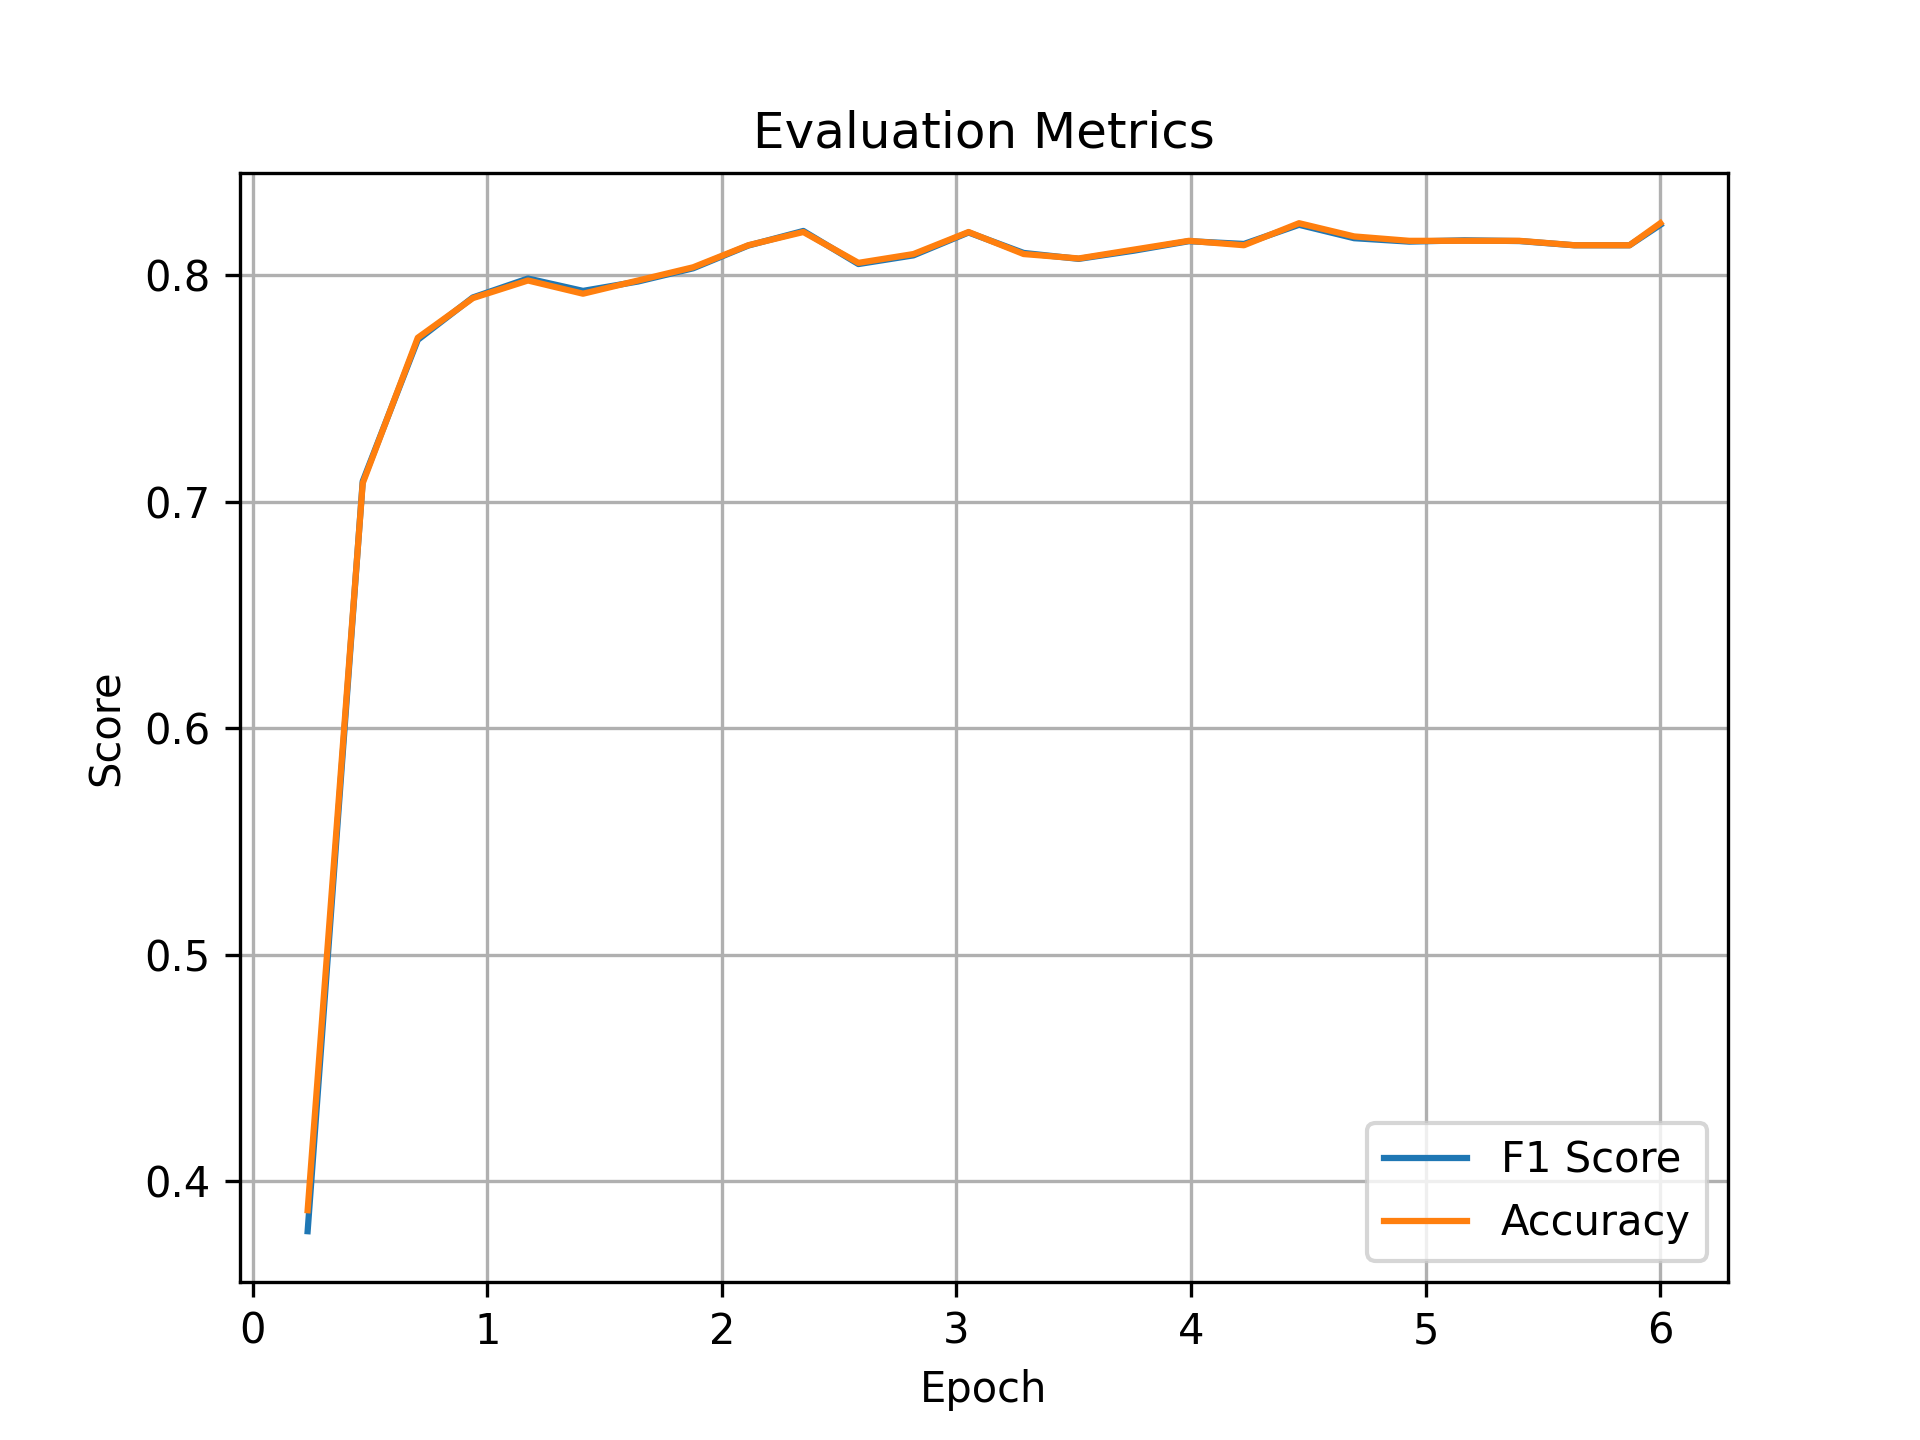

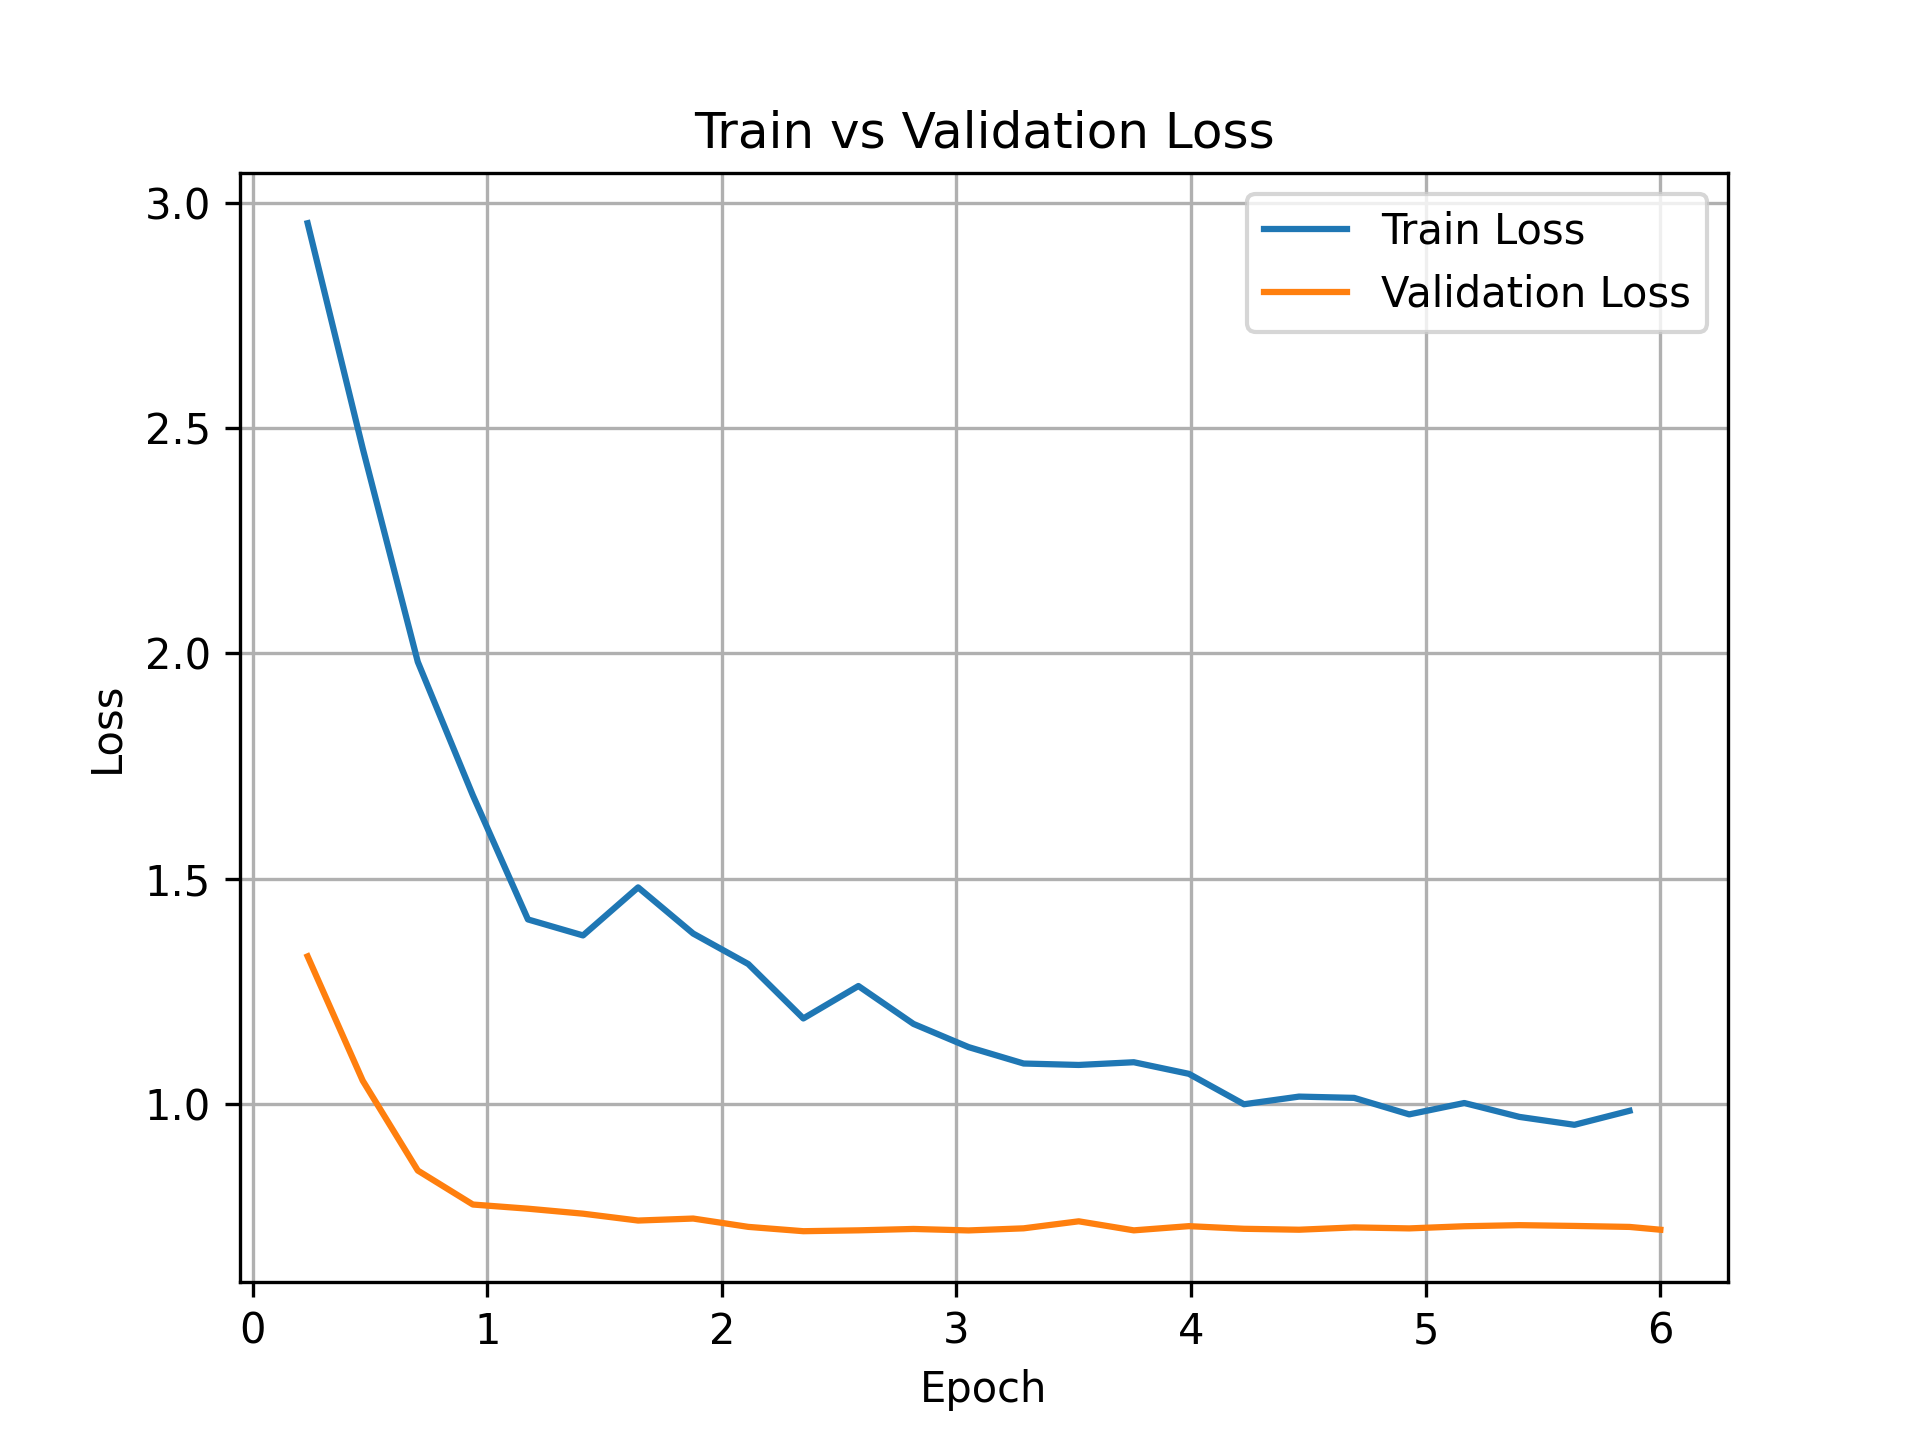

✅ Everything saved safely


In [83]:
!rm -rf /kaggle/working/*
import sys
import os

dummy_path = "/kaggle/working/notebook.py"

# tạo file giả nếu chưa có
if not os.path.exists(dummy_path):
    with open(dummy_path, "w") as f:
        f.write("# dummy file")

# gán _file_ cho notebook
sys.modules["__main__"].__file__ = dummy_path

train(  data_path = "/kaggle/input/datasets/ziaxxx/relabel-dataset/relabel_dataset.csv",
        audio_pkl = "/kaggle/input/datasets/ziaxxx/audio-embedding-wavlm-large/audio_embedding_wavlm_large.pkl",
        video_pkl = "/kaggle/input/datasets/nhatnam2610/video-embedding-pkl/video_embeddings.pkl",
        output_dir = "/kaggle/working/checkpoints",
        final_model_dir = "/kaggle/working/final_model",
        seed = 18,
        need_validation=False,
          
        max_frames = 96,
        image_size = 224,
        dropout = 0.1,
        
        num_train_epochs = 6,
        per_device_train_batch_size = 8,
        per_device_eval_batch_size = 8,
        gradient_accumulation_steps = 2,
        learning_rate = 1e-4,
        weight_decay = 0.01,
        warmup_steps = 100,
        warmup_ratio = 0.1, 
        logging_steps = 50,
        eval_strategy = "steps",
        eval_steps = 50,
        save_strategy = "steps",
        save_steps = 50,
        load_best_model_at_end = True,
        metric_for_best_model = "f1_score",
        fp16 = True,
        dataloader_num_workers = 0,
        remove_unused_columns = False,
        report_to = "none",
        save_total_limit = 3,
        dataloader_drop_last = False, 
        max_grad_norm = 1.0,
        logging_dir="/kaggle/working/runs",
        # EARLYSTOPPING
        early_stopping_patience=15,
        early_stopping_threshold=0.001
        )

## Error analyst

Analyse with hashtags

In [ ]:
# ============================================================
# ERROR ANALYSIS MODULE
# ============================================================
import os, json, pickle
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, classification_report,
    accuracy_score, f1_score
)
from torch.utils.data import DataLoader
import torch


# ─────────────────────────────────────────────
# 1. Load model từ final_model dir
# ─────────────────────────────────────────────
def load_model_for_analysis(
    final_model_dir: str,
    config: SmartMultimodalConfig,
    device: torch.device,
) -> SmartMultimodalModel:
    """Load best model từ final_model dir (do trainer.save_model() lưu)."""
    print(f"📂 Loading model from: {final_model_dir}")

    if not os.path.isdir(final_model_dir):
        raise FileNotFoundError(f"Final model dir not found: {final_model_dir}")

    model = SmartMultimodalModel(config)

    safe_path = os.path.join(final_model_dir, "model.safetensors")
    bin_path  = os.path.join(final_model_dir, "pytorch_model.bin")

    if os.path.exists(safe_path):
        from safetensors.torch import load_file
        state_dict = load_file(safe_path, device=str(device))
        print("  ✅ Loaded from model.safetensors")
    elif os.path.exists(bin_path):
        state_dict = torch.load(bin_path, map_location=device)
        print("  ✅ Loaded from pytorch_model.bin")
    else:
        raise FileNotFoundError(
            f"No weight file found in {final_model_dir}\n"
            f"  Expected: {safe_path}\n       or: {bin_path}"
        )

    model.load_state_dict(state_dict, strict=False)
    model.to(device)
    model.eval()
    print("✅ Model ready for inference")
    return model


# ─────────────────────────────────────────────
# 2. Collect predictions
# ─────────────────────────────────────────────
def collect_predictions(
    model: SmartMultimodalModel,
    dataset,
    dataframe: pd.DataFrame,
    device: torch.device,
    batch_size: int = 8,
    collate_fn=None,
) -> pd.DataFrame:
    """
    Chạy inference toàn bộ dataset, trả về DataFrame có thêm cột:
    true_idx, pred_idx, confidence, is_wrong, prob_vector
    """
    loader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=False,
        drop_last=False,
        collate_fn=collate_fn,
        num_workers=0,
    )

    all_preds, all_probs, all_labels = [], [], []

    with torch.no_grad():
        for batch_idx, batch in enumerate(loader):
            batch = {
                k: v.to(device) if torch.is_tensor(v) else v
                for k, v in batch.items()
            }
            outputs = model(**batch)
            logits  = outputs["logits"]
            probs   = torch.softmax(logits, dim=-1).cpu().numpy()
            preds   = logits.argmax(dim=-1).cpu().numpy()
            labels  = batch["labels"].cpu().numpy()

            all_preds.extend(preds)
            all_probs.extend(probs)
            all_labels.extend(labels)

            if (batch_idx + 1) % 20 == 0:
                print(f"  Processed {batch_idx + 1}/{len(loader)} batches...")

    result_df = dataframe.copy().reset_index(drop=True)
    result_df["true_idx"]   = all_labels
    result_df["pred_idx"]   = all_preds
    result_df["confidence"] = [p[pred] for p, pred in zip(all_probs, all_preds)]
    result_df["is_wrong"]   = result_df["true_idx"] != result_df["pred_idx"]
    result_df["prob_vector"] = [json.dumps(p.tolist()) for p in all_probs]

    print(f"\n📊 Prediction summary:")
    print(f"  Total samples : {len(result_df)}")
    print(f"  Correct       : {(~result_df['is_wrong']).sum()}")
    print(f"  Wrong         : {result_df['is_wrong'].sum()}")
    print(f"  Accuracy      : {(~result_df['is_wrong']).mean()*100:.2f}%")
    return result_df


# ─────────────────────────────────────────────
# 3. Confusion matrix
# ─────────────────────────────────────────────
def plot_confusion_matrix(
    result_df: pd.DataFrame,
    class_names: list,
    save_dir: str,
) -> np.ndarray:
    y_true = result_df["true_idx"].values
    y_pred = result_df["pred_idx"].values

    cm      = confusion_matrix(y_true, y_pred)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    fig, axes = plt.subplots(
        1, 2,
        figsize=(max(12, len(class_names) * 1.2),
                 max(8,  len(class_names) * 0.9))
    )
    for ax, data, title, fmt in zip(
        axes,
        [cm, cm_norm],
        ["Confusion matrix (count)", "Confusion matrix (normalized)"],
        ["d", ".2f"],
    ):
        sns.heatmap(
            data, annot=True, fmt=fmt, cmap="Blues",
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.4, ax=ax,
        )
        ax.set_title(title, fontsize=12)
        ax.set_xlabel("Predicted", fontsize=10)
        ax.set_ylabel("True", fontsize=10)
        ax.tick_params(axis="x", rotation=45, labelsize=8)
        ax.tick_params(axis="y", rotation=0,  labelsize=8)

    plt.tight_layout()
    path = os.path.join(save_dir, "confusion_matrix.png")
    plt.savefig(path, dpi=150, bbox_inches="tight")
    plt.close()
    print(f"💾 Confusion matrix saved → {path}")

    # Per-class stats
    per_class = pd.DataFrame({
        "class":     class_names,
        "n_samples": cm.sum(axis=1),
        "n_correct": cm.diagonal(),
        "recall":    cm_norm.diagonal(),
    })
    per_class["error_rate"] = 1 - per_class["recall"]
    per_class = per_class.sort_values("error_rate", ascending=False)

    print("\n🔍 Per-class error rates (worst first):")
    print(per_class.to_string(index=False))
    per_class.to_csv(os.path.join(save_dir, "per_class_stats.csv"), index=False)

    return cm


# ─────────────────────────────────────────────
# 4. Lưu wrong samples
# ─────────────────────────────────────────────
def save_wrong_samples(
    result_df: pd.DataFrame,
    class_names: list,
    save_dir: str,
    top_k: int = 200,
) -> pd.DataFrame:
    idx2cls  = {i: c for i, c in enumerate(class_names)}
    wrong_df = result_df[result_df["is_wrong"]].copy()

    wrong_df["true_label"] = wrong_df["true_idx"].map(idx2cls)
    wrong_df["pred_label"] = wrong_df["pred_idx"].map(idx2cls)
    wrong_df["error_pair"] = wrong_df["true_label"] + " → " + wrong_df["pred_label"]

    # Model tự tin cao nhưng vẫn sai = nguy hiểm nhất → lên đầu
    wrong_df = wrong_df.sort_values("confidence", ascending=False)

    csv_path  = os.path.join(save_dir, "wrong_predictions.csv")
    json_path = os.path.join(save_dir, "wrong_predictions.json")

    wrong_df.drop(columns=["prob_vector"], errors="ignore").to_csv(csv_path, index=False)
    wrong_df.head(top_k).drop(columns=["prob_vector"], errors="ignore").to_json(
        json_path, orient="records", force_ascii=False, indent=2
    )
    print(f"💾 Wrong samples saved → {csv_path} ({len(wrong_df)} rows)")

    # Top confused pairs
    pair_counts = wrong_df["error_pair"].value_counts().head(20)
    print("\n🔴 Top confused class pairs:")
    print(pair_counts.to_string())
    pair_counts.to_csv(os.path.join(save_dir, "top_confused_pairs.csv"), header=["count"])

    # Bar chart top confused pairs
    fig, ax = plt.subplots(figsize=(10, max(4, len(pair_counts) * 0.4)))
    pair_counts[::-1].plot(kind="barh", ax=ax, color="salmon")
    ax.set_title("Top confused class pairs", fontsize=12)
    ax.set_xlabel("Count", fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, "top_confused_pairs.png"), dpi=150, bbox_inches="tight")
    plt.close()

    return wrong_df


# ─────────────────────────────────────────────
# 6. Master runner
# ─────────────────────────────────────────────
def run_error_analysis(
    data_path:       str = "/kaggle/input/datasets/ziaxxx/relabel-dataset/relabel_dataset.csv",
    analysis_dir:    str = "/kaggle/working/error_analysis",
    final_model_dir: str = "/kaggle/working/final_model",
    audio_pkl:     str = "path_to_your.pkl",
    video_pkl:     str = "path_to_your.pkl",
    
   
    batch_size:      int = 8,
    top_n:           int = 30,
):
    os.makedirs(analysis_dir, exist_ok=True)
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    # ── Load video vectors ──
    with open(video_pkl, "rb") as f:
        pkl_video = pickle.load(f)
    
    video_embedding_map = {
        item.video_path: torch.tensor(item.embedding, dtype=torch.float32)
        for item in pkl_video
    }
    print(f"  {len(video_embedding_map)} video embeddings loaded")

    # ── Load audio vectors ──
    with open(audio_pkl, "rb") as f:
        pkl_audio = pickle.load(f)
    
    audio_embedding_map = {
        item.video_path: torch.tensor(item.embedding, dtype=torch.float32)
        for item in pkl_audio
    }
    print(f"  {len(audio_embedding_map)} audio embeddings loaded")
        
    # ── Load data ──
    print("\n📂 Loading dataset...")
    global data_manager
    data_manager = SmartDataManager(data_path)
    data_manager.load_data()


    config    = SmartMultimodalConfig(
        num_classes     = data_manager.num_classes,
        max_frames      = 96,
        image_size      = 224,
        dropout         = 0.1,
    )

    # ── Load final model
    model = load_model_for_analysis(final_model_dir, config, device)

    # ── Build test split
    # validator    = SmartVideoValidator(strict_mode=False)
    _, _, test_df = data_manager.get_smart_splits(need_validation = False)
    test_dataset = SmartDataset(
        test_df, video_embedding_map, audio_embedding_map, dataset_name="TEST"
    )
    print(f"\n📊 Test set: {len(test_dataset)} samples | {data_manager.num_classes} classes")

    # ── Collect predictions 
    result_df = collect_predictions(
        model, test_dataset, test_df, device,
        batch_size=batch_size,
        collate_fn=smart_collate_fn  
    )

    # ── Confusion matrix ──
    print("\n🔢 Computing confusion matrix...")
    cm = plot_confusion_matrix(result_df, data_manager.classes, analysis_dir)

    # ── Wrong samples ──
    print("\n💾 Saving wrong predictions...")
    wrong_df = save_wrong_samples(result_df, data_manager.classes, analysis_dir)

    # # ── Hashtag error analysis ──
    # print("\n🏷️  Running hashtag error analysis...")
    # hashtag_error_analysis(
    #     result_df, data_manager.classes, analysis_dir,
    #     hashtag_col=hashtag_col, top_n=top_n,
    # )

    # ── Classification report ──
    y_true = result_df["true_idx"].values
    y_pred = result_df["pred_idx"].values
    print(f"\n📋 Classification report:")
    print("-" * 60)
    print(classification_report(y_true, y_pred, target_names=data_manager.classes, digits=4, zero_division=0))

    # ── Final summary JSON ──
    summary = {
        "final_model_dir": final_model_dir,
        "total_samples":   int(len(result_df)),
        "total_errors":    int(result_df["is_wrong"].sum()),
        "accuracy":        float(accuracy_score(y_true, y_pred)),
        "f1_macro":        float(f1_score(y_true, y_pred, average="macro",  zero_division=0)),
        "f1_weighted":     float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "classification_report": classification_report(
            y_true, y_pred,
            target_names=data_manager.classes,
            output_dict=True,
            zero_division=0,
        ),
    }
    summary_path = os.path.join(analysis_dir, "error_analysis_summary.json")
    with open(summary_path, "w") as f:
        json.dump(summary, f, indent=2, ensure_ascii=False)

    print("\n" + "=" * 60)
    print("✅ ERROR ANALYSIS COMPLETE")
    print(f"   Model       : {final_model_dir}")
    print(f"   Accuracy    : {summary['accuracy']*100:.2f}%")
    print(f"   F1 macro    : {summary['f1_macro']:.4f}")
    print(f"   F1 weighted : {summary['f1_weighted']:.4f}")
    print(f"   Errors      : {summary['total_errors']} / {summary['total_samples']}")
    print(f"   Outputs  →  {analysis_dir}/")
    print("=" * 60)

    return result_df, wrong_df, summary

In [ ]:
# ─────────────────────────────────────────────
# Entry point
# ─────────────────────────────────────────────
if __name__ == "__main__":
    result_df, wrong_df, summary = run_error_analysis(
        data_path       = "/kaggle/input/datasets/ziaxxx/relabel-dataset/relabel_dataset.csv",
        analysis_dir = "/kaggle/working/error_analysis",
        final_model_dir = "/kaggle/working/final_model",
        audio_pkl       = "/kaggle/input/datasets/ziaxxx/audio-embedding-wavlm-large/audio_embedding_wavlm_large.pkl",
        video_pkl       = "/kaggle/input/datasets/nhatnam2610/video-embedding-pkl/video_embeddings.pkl",
        batch_size      = 8,
        top_n           = 30,           # số hashtag hiển thị trong chart/heatmap
    )

In [ ]:
import shutil

shutil.make_archive(
    "/kaggle/working",  # tên file zip
    'zip',
    "/kaggle/working"   # folder cần zip
)

In [84]:
!zip -r final_model.zip /kaggle/working
from IPython.display import FileLink
FileLink(r'final_model.zip')

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/environment_info.json (deflated 13%)
  adding: kaggle/working/.virtual_documents/ (stored 0%)
  adding: kaggle/working/.virtual_documents/__notebook_source__.ipynb (deflated 77%)
  adding: kaggle/working/.ipynb_checkpoints/ (stored 0%)
  adding: kaggle/working/metrics_curve.png (deflated 17%)
  adding: kaggle/working/notebook.py (stored 0%)
  adding: kaggle/working/training_history.json (deflated 80%)
  adding: kaggle/working/loss_curve.png (deflated 15%)
  adding: kaggle/working/checkpoints/ (stored 0%)
  adding: kaggle/working/checkpoints/checkpoint-1250/ (stored 0%)
  adding: kaggle/working/checkpoints/checkpoint-1250/rng_state.pth (deflated 26%)
  adding: kaggle/working/checkpoints/checkpoint-1250/scheduler.pt (deflated 62%)
  adding: kaggle/working/checkpoints/checkpoint-1250/trainer_state.json (deflated 77%)
  adding: kaggle/working/checkpoints/checkpoint-1250/model.safetensors (deflated 8%)
  adding: kaggle/working/c

/kaggle/working/final_model.zip

In [71]:
!ls -lh final_model.zip

-rw-r--r-- 1 root root 2.2M May 28 08:01 final_model.zip
